In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import exposure # Para CLAHE en color
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, opening, closing, disk
from skimage.measure import label, regionprops

In [30]:
params_set8 = {
    "clahe_clip_limit": 2.0,
    "bright_thresh": 220,        # Muy bajo
    "dark_thresh_factor": 1.15,  # Bastante sensible a oscuros
    "low_sat_thresh": 100,       # Muy alto (muy sensible a desaturación)
    "very_dark_val_thresh": 100, # Muy alto (muy sensible a valores bajos/oscuridad)
    "line_threshold": 45,        # Moderado, el foco es el color
    "opening_disk_radius": 1,
    "closing_disk_radius": 5,    # Conectar bien las regiones de color
    "min_size_noise": 30,
    "crack_lower_intensity_bound":70 # Pixels darker than this are excluded from dark_mask (e.g. pure black
}
param_sets_to_test = [
    {"name": "", **params_set8}
]

In [31]:
def show_images(images, titles=None, cmap_list=None):
    """Helper function to display multiple images"""
    n_images = len(images)
    if titles is None:
        titles = ['Image %d' % (i+1) for i in range(n_images)]
    if cmap_list is None:
        cmap_list = [None] * n_images

    # Ajustar el tamaño de la figura dinámicamente
    cols = min(n_images, 4) # Mostrar un máximo de 4 imágenes por fila
    rows = (n_images + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 5 * rows)) # Ajustar el tamaño por imagen

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        if cmap_list[i] == 'gray':
            plt.imshow(images[i], cmap='gray')
        else:
            # Asegurar que las imágenes BGR se muestren correctamente
            if len(images[i].shape) == 3 and images[i].shape[2] == 3:
                 plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
            else: # Para imágenes en escala de grises o ya en RGB
                 plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [32]:
damage_params = {
    "clahe_clip_limit": 2.0,
    "fissure_opening_radius": 1,
    "fissure_closing_radius": 5,
    "fissure_min_area": 30
}

def detect_damage_02(img_bgr,
                  clahe_clip_limit=1.5,
                  fissure_opening_radius=1,
                  fissure_closing_radius=3,
                  fissure_min_area=50,
                  brown_lower = np.array([20, 30, 30]),
                  brown_upper = np.array([30, 255, 150]), # Marrón oscuro
                  ):
    # --- 1. Preprocessing for Crack and Detail Enhancement ---
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)

    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # --- 2. Brown Color Filtering for Crack Detection ---
    # Define brown color range in HSV (this can be further tuned)
    brown_lower_1 = brown_lower
    brown_upper_1 = brown_upper

    hsv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    brown_mask = cv2.inRange(hsv_img, brown_lower_1, brown_upper_1)

    fissure_candidate_mask = brown_mask.copy()

    # --- 3. Morphological Operations ---
    selem_fissure_opening = disk(fissure_opening_radius)
    fissures_opened = opening(fissure_candidate_mask, selem_fissure_opening)

    selem_fissure_closing = disk(fissure_closing_radius)
    fissures_closed = closing(fissures_opened, selem_fissure_closing)

    fissures_cleaned_bool = fissures_closed.astype(bool)
    fissures_final_bool = remove_small_objects(fissures_cleaned_bool, min_size=fissure_min_area)
    fissure_mask_refined = fissures_final_bool.astype(np.uint8) * 255

    # --- 4. Final Output ---
    final_mask = fissure_mask_refined

    return final_mask


In [33]:
def calculate_metrics(predicted_mask, ground_truth_mask, epsilon=1e-6):
    """Calculates Intersection over Union (IoU), Dice Coefficient, Precision, Recall, and Accuracy."""
    predicted_mask_bool = predicted_mask.astype(bool)
    ground_truth_mask_bool = ground_truth_mask.astype(bool)

    tp = np.sum(np.logical_and(predicted_mask_bool, ground_truth_mask_bool))
    fp = np.sum(np.logical_and(predicted_mask_bool, np.logical_not(ground_truth_mask_bool)))
    fn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), ground_truth_mask_bool))
    tn = np.sum(np.logical_and(np.logical_not(predicted_mask_bool), np.logical_not(ground_truth_mask_bool)))

    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    precision = (tp + epsilon) / (tp + fp + epsilon)
    recall = (tp + epsilon) / (tp + fn + epsilon)
    accuracy = (tp + tn + epsilon) / (tp + fp + fn + tn + epsilon)

    return {
        "iou": iou, "dice": dice, "precision": precision, "recall": recall,
        "accuracy": accuracy, "tp": tp, "fp": fp, "fn": fn, "tn": tn
    }

In [34]:
param_sets_cracks = {
        "clahe_clip_limit": 0.2,
        "line_threshold": 50,
        "opening_radius": 1.85,
        "closing_radius": 1.85,
        "min_fissure_area": 30
    }


def detect_thin_cracks(
    img_bgr,
    clahe_clip_limit=0.3,
    line_threshold=30,
    opening_radius=1,
    closing_radius=2,
    min_fissure_area=10,
    min_aspect_ratio=1.5
):
    # 1. Enhance local contrast
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clahe_clip_limit, tileGridSize=(8,8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge([l_enhanced, a, b])
    grayscale = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)
    grayscale = cv2.cvtColor(grayscale, cv2.COLOR_BGR2GRAY)

    # 2. Edge detection (Sobel)
    sobel_x = cv2.Sobel(grayscale, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(grayscale, cv2.CV_64F, 0, 1, ksize=3)
    abs_sobel_x = cv2.convertScaleAbs(sobel_x)
    abs_sobel_y = cv2.convertScaleAbs(sobel_y)
    edge_response = cv2.addWeighted(abs_sobel_x, 0.5, abs_sobel_y, 0.5, 0)
    edge_response = cv2.normalize(edge_response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 3. Threshold to binarize edges
    _, edge_mask = cv2.threshold(edge_response, line_threshold, 255, cv2.THRESH_BINARY)

    # 4. Morphological cleaning (preserve thin lines)
    se_open = disk(opening_radius)
    se_close = disk(closing_radius)
    mask_open = opening(edge_mask, se_open)
    mask_close = closing(mask_open, se_close)

    # 5. Remove small objects, keep only elongated ones
    mask_bool = mask_close.astype(bool)
    label_img = label(mask_bool)
    props = regionprops(label_img)
    final_mask = np.zeros_like(mask_close, dtype=np.uint8)
    for prop in props:
        if prop.area >= min_fissure_area:
            # Aspect ratio: major_axis_length / minor_axis_length
            if prop.minor_axis_length > 0:
                aspect = prop.major_axis_length / prop.minor_axis_length
            else:
                aspect = 0
            if aspect >= min_aspect_ratio:
                final_mask[label_img == prop.label] = 255

    return final_mask, grayscale, edge_response, edge_mask

In [35]:
# --- Run in 10 random images and show the results and comparation with label ---
""" images_folder = 'dataset_con_filtro/img'
labels_folder = 'dataset_con_filtro/img_filter'

image_files = [f for f in os.listdir(images_folder) if f.endswith('.jpg') or f.endswith('.png')]
np.random.seed(42)  # For reproducibility
selected_files = np.random.choice(image_files, size=10, replace=False)

params = {
    "clahe_clip_limit": 2.0,
}

for file_name in selected_files:
    img_path = os.path.join(images_folder, file_name)
    label_path = os.path.join(labels_folder, file_name.replace('.jpg', '.png').replace('.png', '.png'))

    img_bgr = cv2.imread(img_path)
    label_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

    if img_bgr is None or label_mask is None:
        print(f"Error loading image or label for {file_name}. Skipping.")
        continue

    # Detect damage
    final_mask = detect_damage_02(
        img_bgr.copy(), **params)
    
    # Detect thin cracks
    thin_crack_mask, grayscale, edge_response, edge_mask = detect_thin_cracks(
        img_bgr.copy(), **param_sets_cracks)

    # Calculate metrics
    metrics = calculate_metrics(final_mask, label_mask)

    # Show results
    show_images([img_bgr, final_mask, thin_crack_mask, label_mask],
                titles=["Original Image", "Detected Damage (Pipeline 1)", "Detected Thin Cracks (Pipeline 2)", "Ground Truth"],
                cmap_list=['bgr', 'gray', 'gray', 'gray'])
    

    print(f"Metrics for {file_name}: {metrics}") """

' images_folder = \'dataset_con_filtro/img\'\nlabels_folder = \'dataset_con_filtro/img_filter\'\n\nimage_files = [f for f in os.listdir(images_folder) if f.endswith(\'.jpg\') or f.endswith(\'.png\')]\nnp.random.seed(42)  # For reproducibility\nselected_files = np.random.choice(image_files, size=10, replace=False)\n\nparams = {\n    "clahe_clip_limit": 2.0,\n}\n\nfor file_name in selected_files:\n    img_path = os.path.join(images_folder, file_name)\n    label_path = os.path.join(labels_folder, file_name.replace(\'.jpg\', \'.png\').replace(\'.png\', \'.png\'))\n\n    img_bgr = cv2.imread(img_path)\n    label_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)\n\n    if img_bgr is None or label_mask is None:\n        print(f"Error loading image or label for {file_name}. Skipping.")\n        continue\n\n    # Detect damage\n    final_mask = detect_damage_02(\n        img_bgr.copy(), **params)\n\n    # Detect thin cracks\n    thin_crack_mask, grayscale, edge_response, edge_mask = detect_th

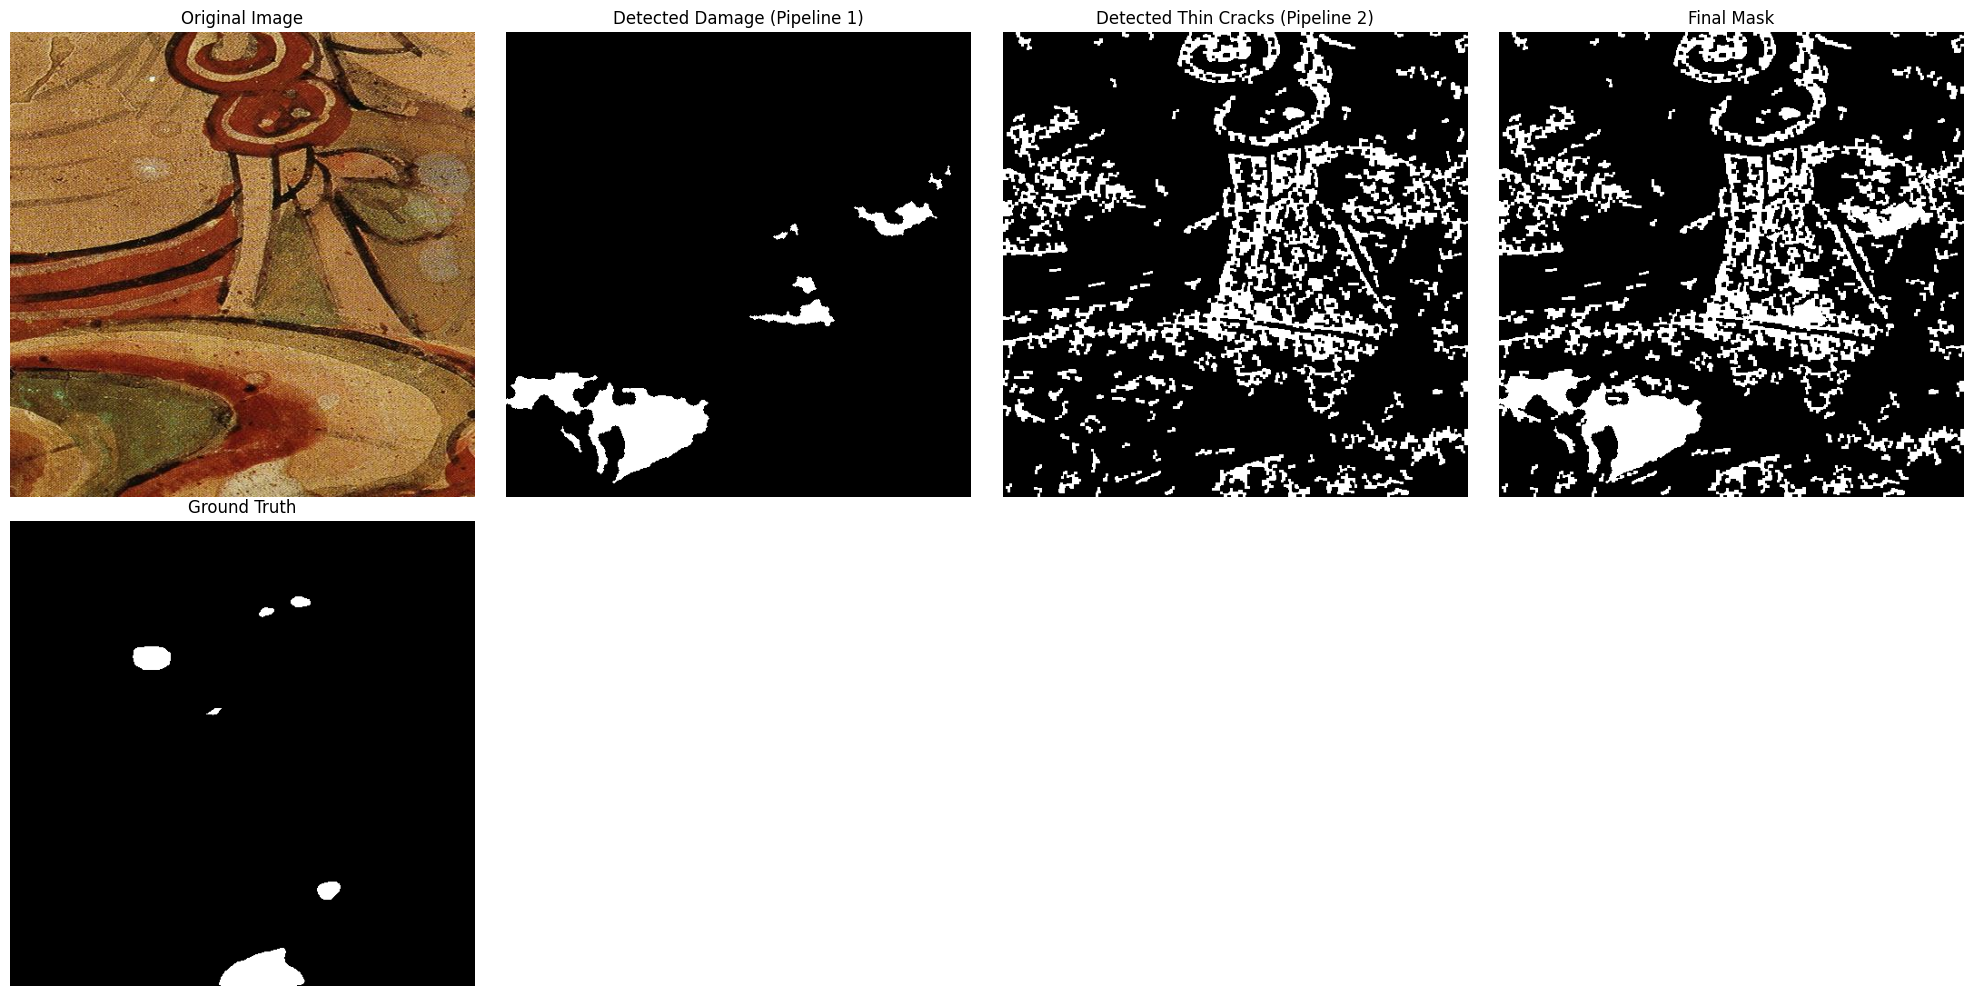

Metrics for 000931.png: Damage - {'iou': np.float64(5.6151384128465866e-11), 'dice': np.float64(5.6151384128465866e-11), 'precision': np.float64(7.416196973641634e-11), 'recall': np.float64(2.3121387277891006e-10), 'accuracy': np.float64(0.9320640563967435), 'tp': np.int64(0), 'fp': np.int64(13484), 'fn': np.int64(4325), 'tn': np.int64(244335)}, Thin Cracks - {'iou': np.float64(0.027633309147103543), 'dice': np.float64(0.05378048549390232), 'precision': np.float64(0.029311349841175133), 'recall': np.float64(0.32554913310391925), 'accuracy': np.float64(0.8110008239753304), 'tp': np.int64(1408), 'fp': np.int64(46628), 'fn': np.int64(2917), 'tn': np.int64(211191)}, Final - {'iou': np.float64(0.02266361911240602), 'dice': np.float64(0.044322724855284996), 'precision': np.float64(0.023780168571943792), 'recall': np.float64(0.32554913310391925), 'accuracy': np.float64(0.7683792114266648)}


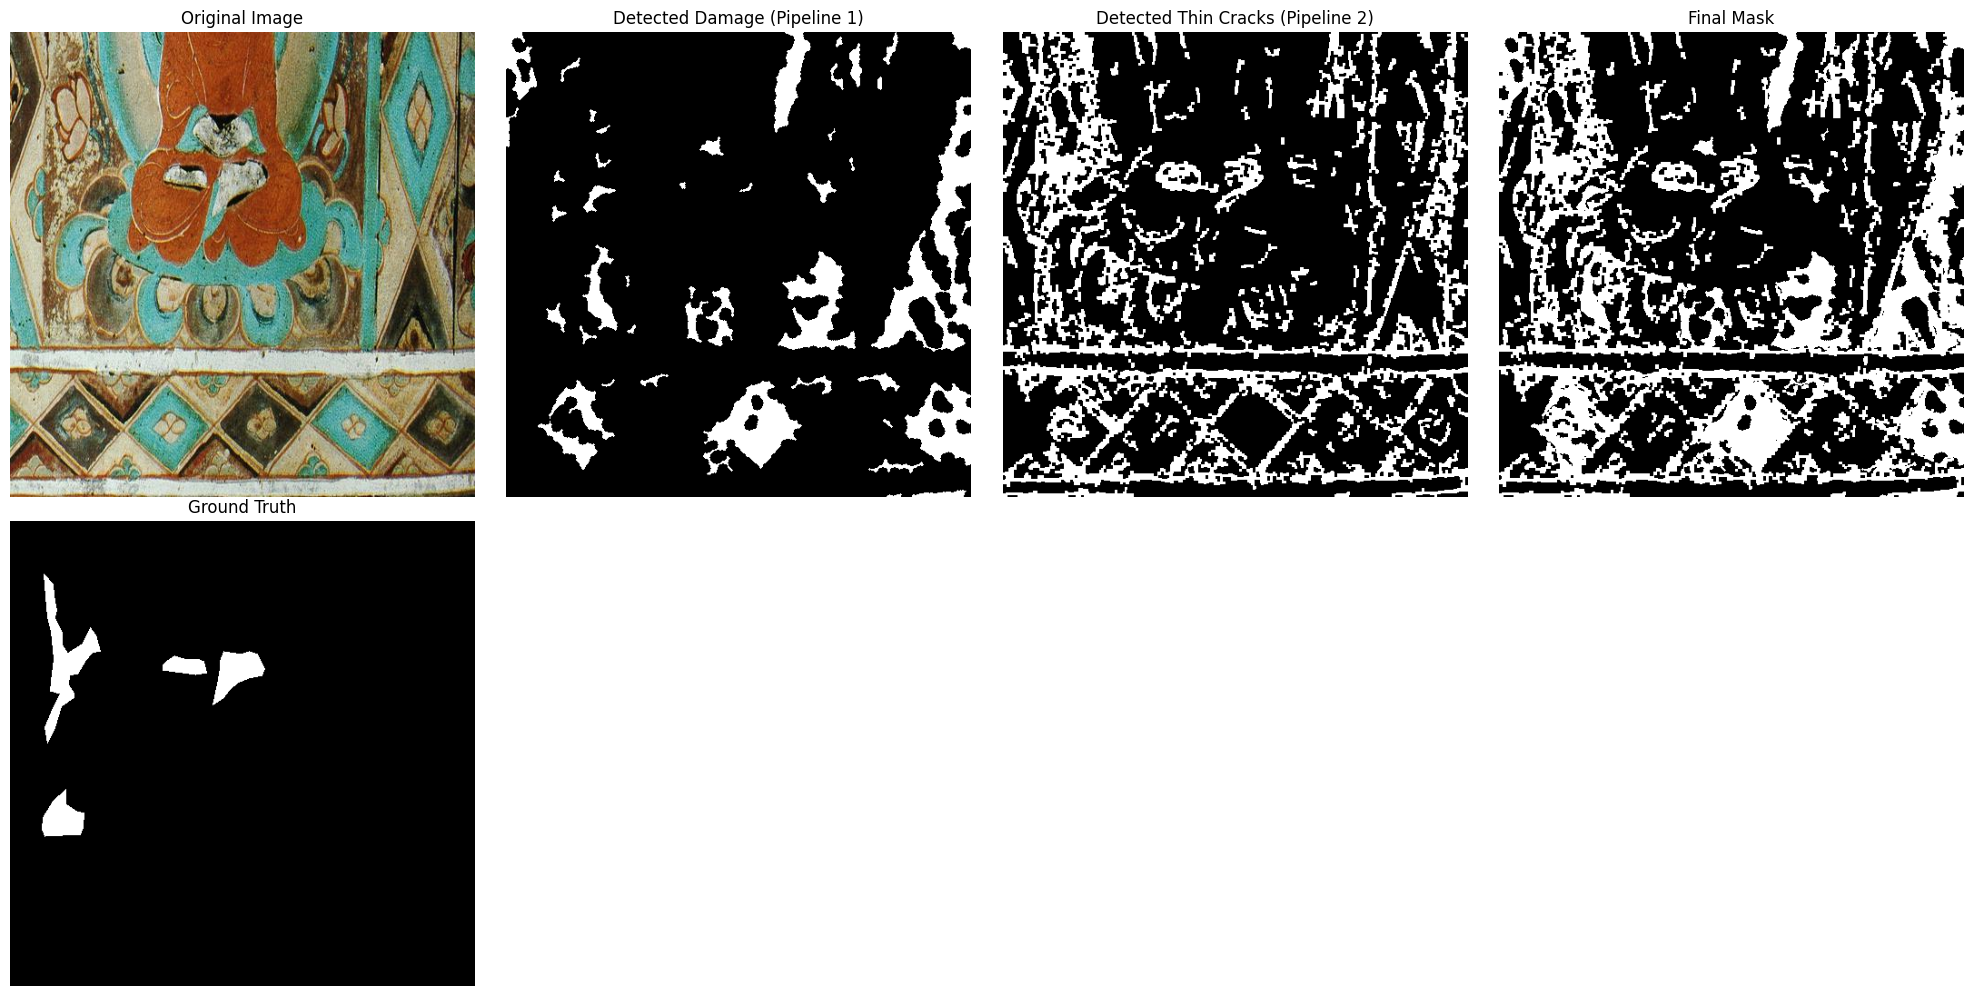

Metrics for 000415.png: Damage - {'iou': np.float64(0.01218145133616866), 'dice': np.float64(0.024069698783617106), 'precision': np.float64(0.014650807471772455), 'recall': np.float64(0.06740179199622304), 'accuracy': np.float64(0.8487319946294833), 'tp': np.int64(489), 'fp': np.int64(32888), 'fn': np.int64(6766), 'tn': np.int64(222001)}, Thin Cracks - {'iou': np.float64(0.06238414374643685), 'dice': np.float64(0.11744178244255499), 'precision': np.float64(0.06505576209568692), 'recall': np.float64(0.603032391508886), 'accuracy': np.float64(0.749164581299785), 'tp': np.int64(4375), 'fp': np.int64(62875), 'fn': np.int64(2880), 'tn': np.int64(192014)}, Final - {'iou': np.float64(0.06963974169812402), 'dice': np.float64(0.1340594849733888), 'precision': np.float64(0.07217775737622414), 'recall': np.float64(0.940848926402982), 'accuracy': np.float64(1.4229087829611857)}


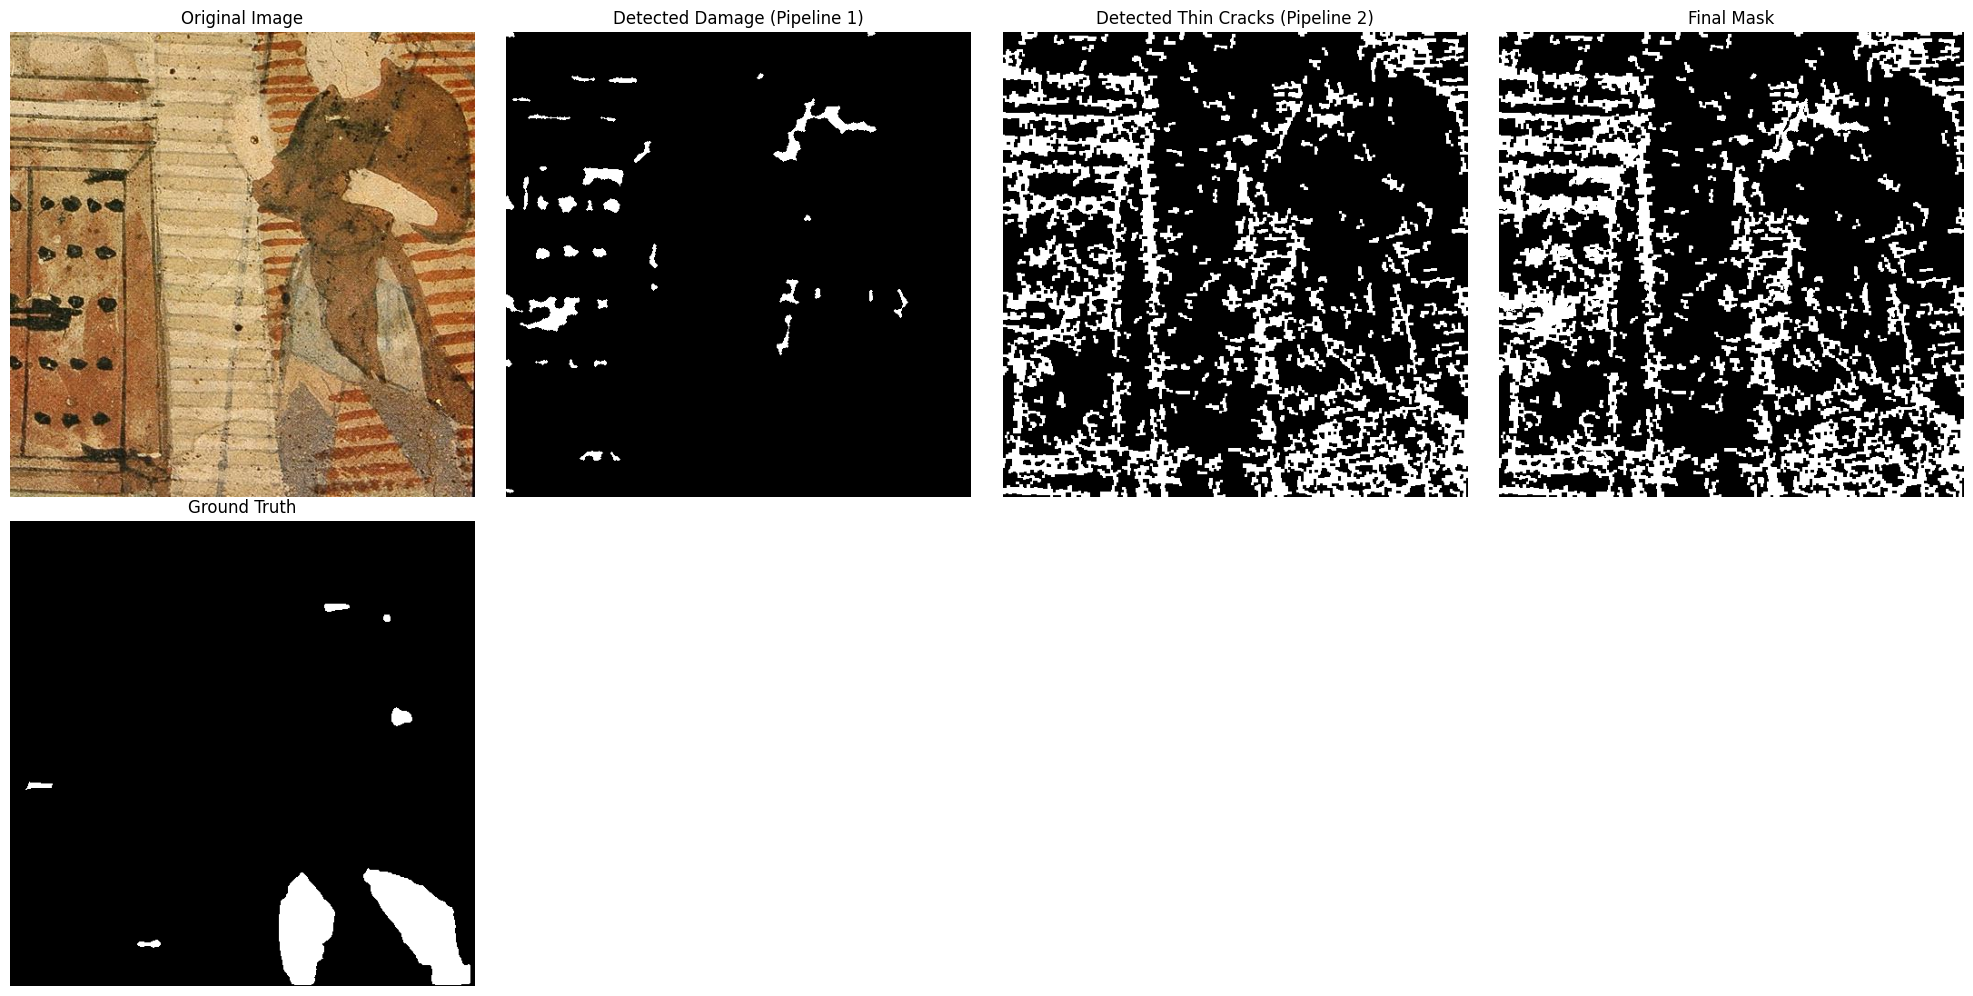

Metrics for 000835.png: Damage - {'iou': np.float64(0.006106793226702998), 'dice': np.float64(0.012139453272528746), 'precision': np.float64(0.01830282876746289), 'recall': np.float64(0.009081357024235863), 'accuracy': np.float64(0.9248771667483334), 'tp': np.int64(121), 'fp': np.int64(6490), 'fn': np.int64(13203), 'tn': np.int64(242330)}, Thin Cracks - {'iou': np.float64(0.07219330257765116), 'dice': np.float64(0.13466471465226842), 'precision': np.float64(0.08080428875285986), 'recall': np.float64(0.4038577004350152), 'accuracy': np.float64(0.7361946105967094), 'tp': np.int64(5381), 'fp': np.int64(61212), 'fn': np.int64(7943), 'tn': np.int64(187608)}, Final - {'iou': np.float64(0.1382420976475847), 'dice': np.float64(0.2624559002759868), 'precision': np.float64(0.14849384510960212), 'recall': np.float64(1.3451569420586178), 'accuracy': np.float64(2.143909454348969)}


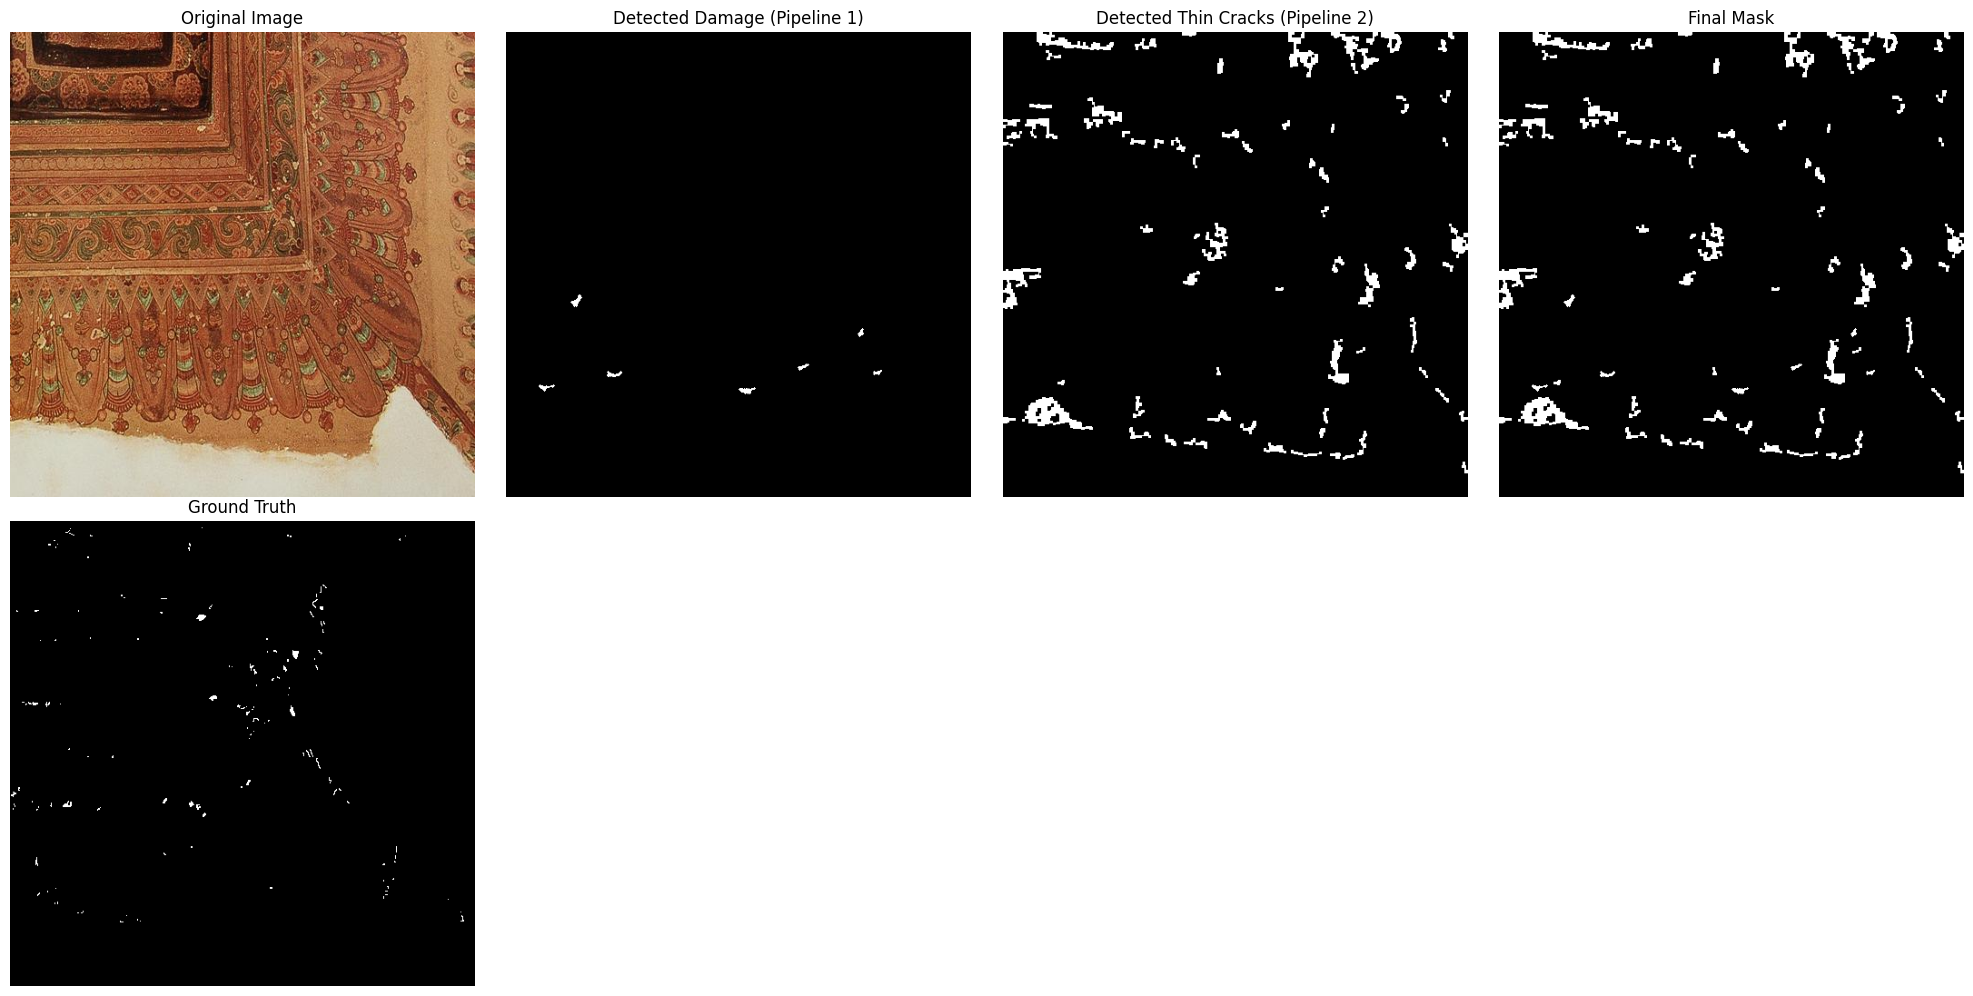

Metrics for img_1158crop_1_1.png: Damage - {'iou': np.float64(7.507507501871239e-10), 'dice': np.float64(7.507507501871239e-10), 'precision': np.float64(2.564102557527942e-09), 'recall': np.float64(1.0615711241384596e-09), 'accuracy': np.float64(0.9949188232422069), 'tp': np.int64(0), 'fp': np.int64(390), 'fn': np.int64(942), 'tn': np.int64(260812)}, Thin Cracks - {'iou': np.float64(0.007944643857171993), 'dice': np.float64(0.015764047884077967), 'precision': np.float64(0.008565902274240958), 'recall': np.float64(0.09872611560644785), 'accuracy': np.float64(0.9556999206544659), 'tp': np.int64(93), 'fp': np.int64(10764), 'fn': np.int64(849), 'tn': np.int64(250438)}, Final - {'iou': np.float64(0.14593058979311307), 'dice': np.float64(0.2777155607062715), 'precision': np.float64(0.15676271689689927), 'recall': np.float64(1.4438830576650656), 'accuracy': np.float64(3.0981216430698466)}


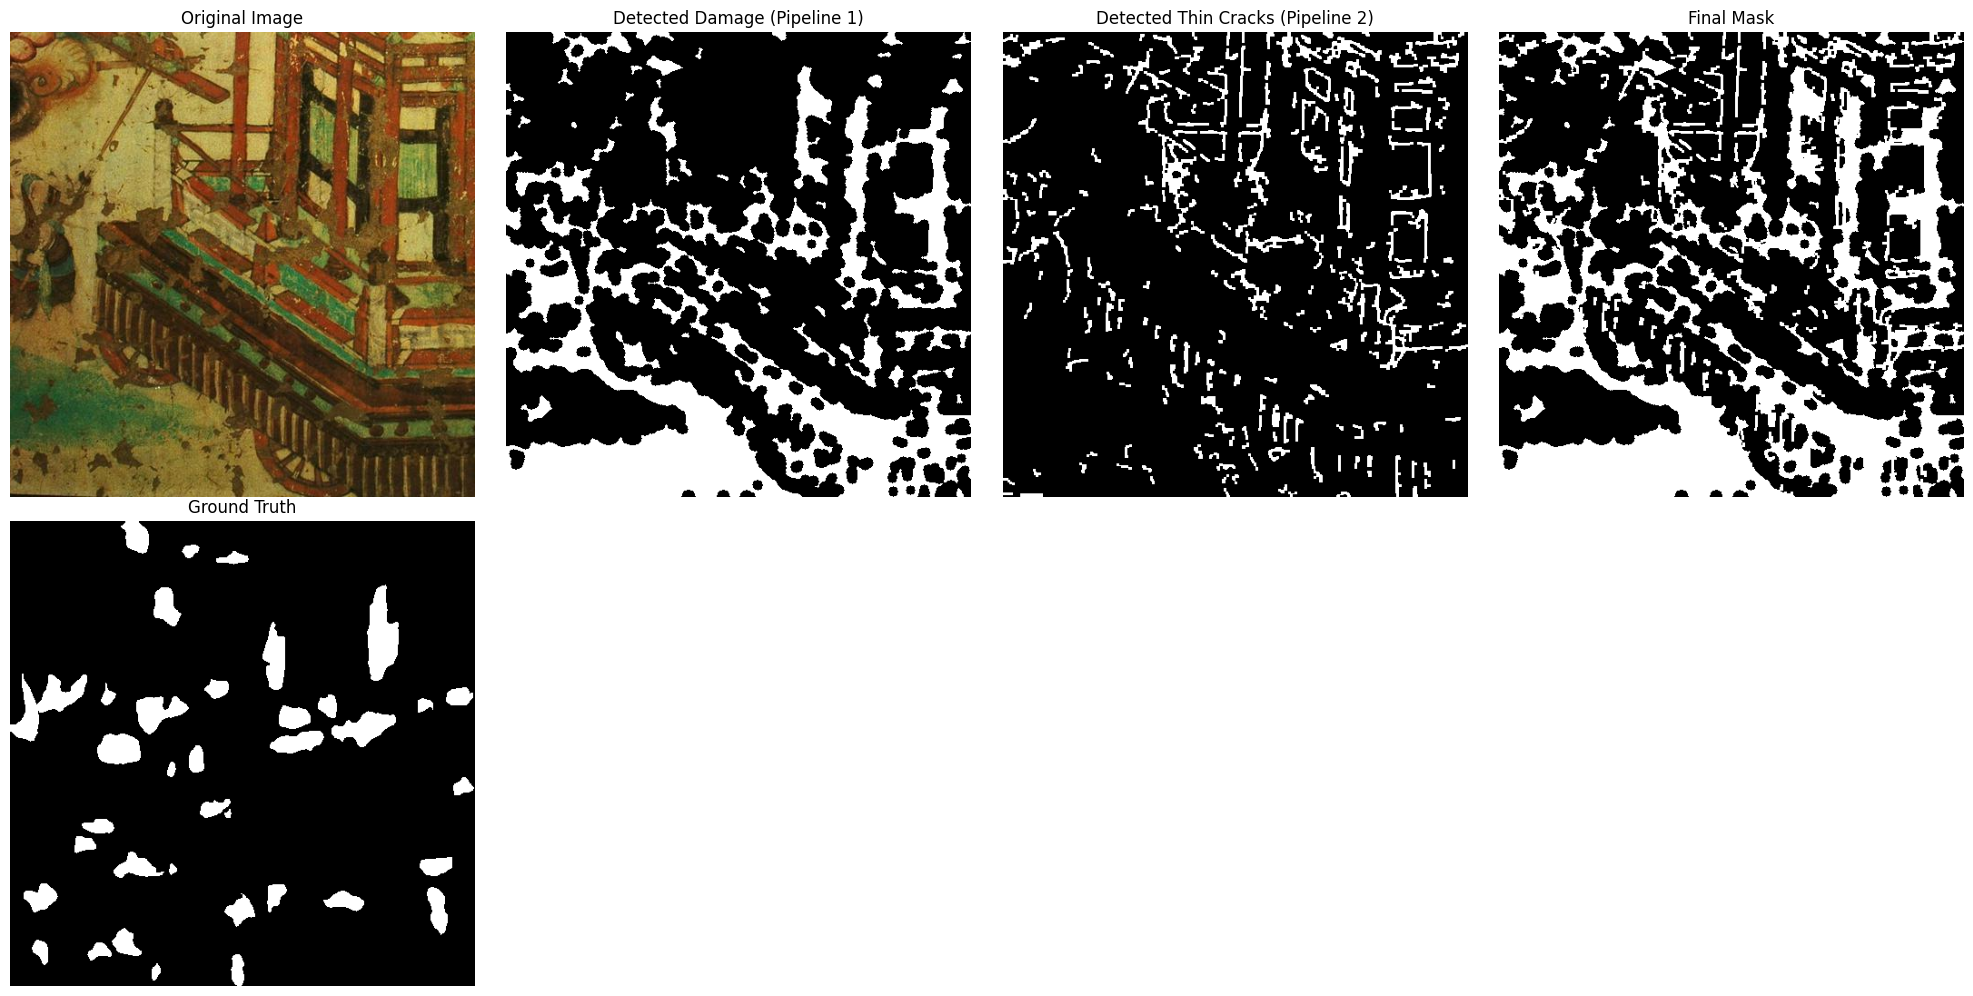

Metrics for 001006.png: Damage - {'iou': np.float64(0.10240392478492884), 'dice': np.float64(0.18578294666443382), 'precision': np.float64(0.12212976207096439), 'recall': np.float64(0.3880122273881357), 'accuracy': np.float64(0.6859283447277607), 'tp': np.int64(9393), 'fp': np.int64(67517), 'fn': np.int64(14815), 'tn': np.int64(170419)}, Thin Cracks - {'iou': np.float64(0.03336174359687159), 'dice': np.float64(0.06456934136395724), 'precision': np.float64(0.06154076517700304), 'recall': np.float64(0.06791143427511932), 'accuracy': np.float64(0.818290710449912), 'tp': np.int64(1644), 'fp': np.int64(25070), 'fn': np.int64(22564), 'tn': np.int64(212866)}, Final - {'iou': np.float64(0.2387556481399635), 'dice': np.float64(0.44759647189884866), 'precision': np.float64(0.26351424170085846), 'recall': np.float64(1.8596133947678526), 'accuracy': np.float64(3.722927093510731)}


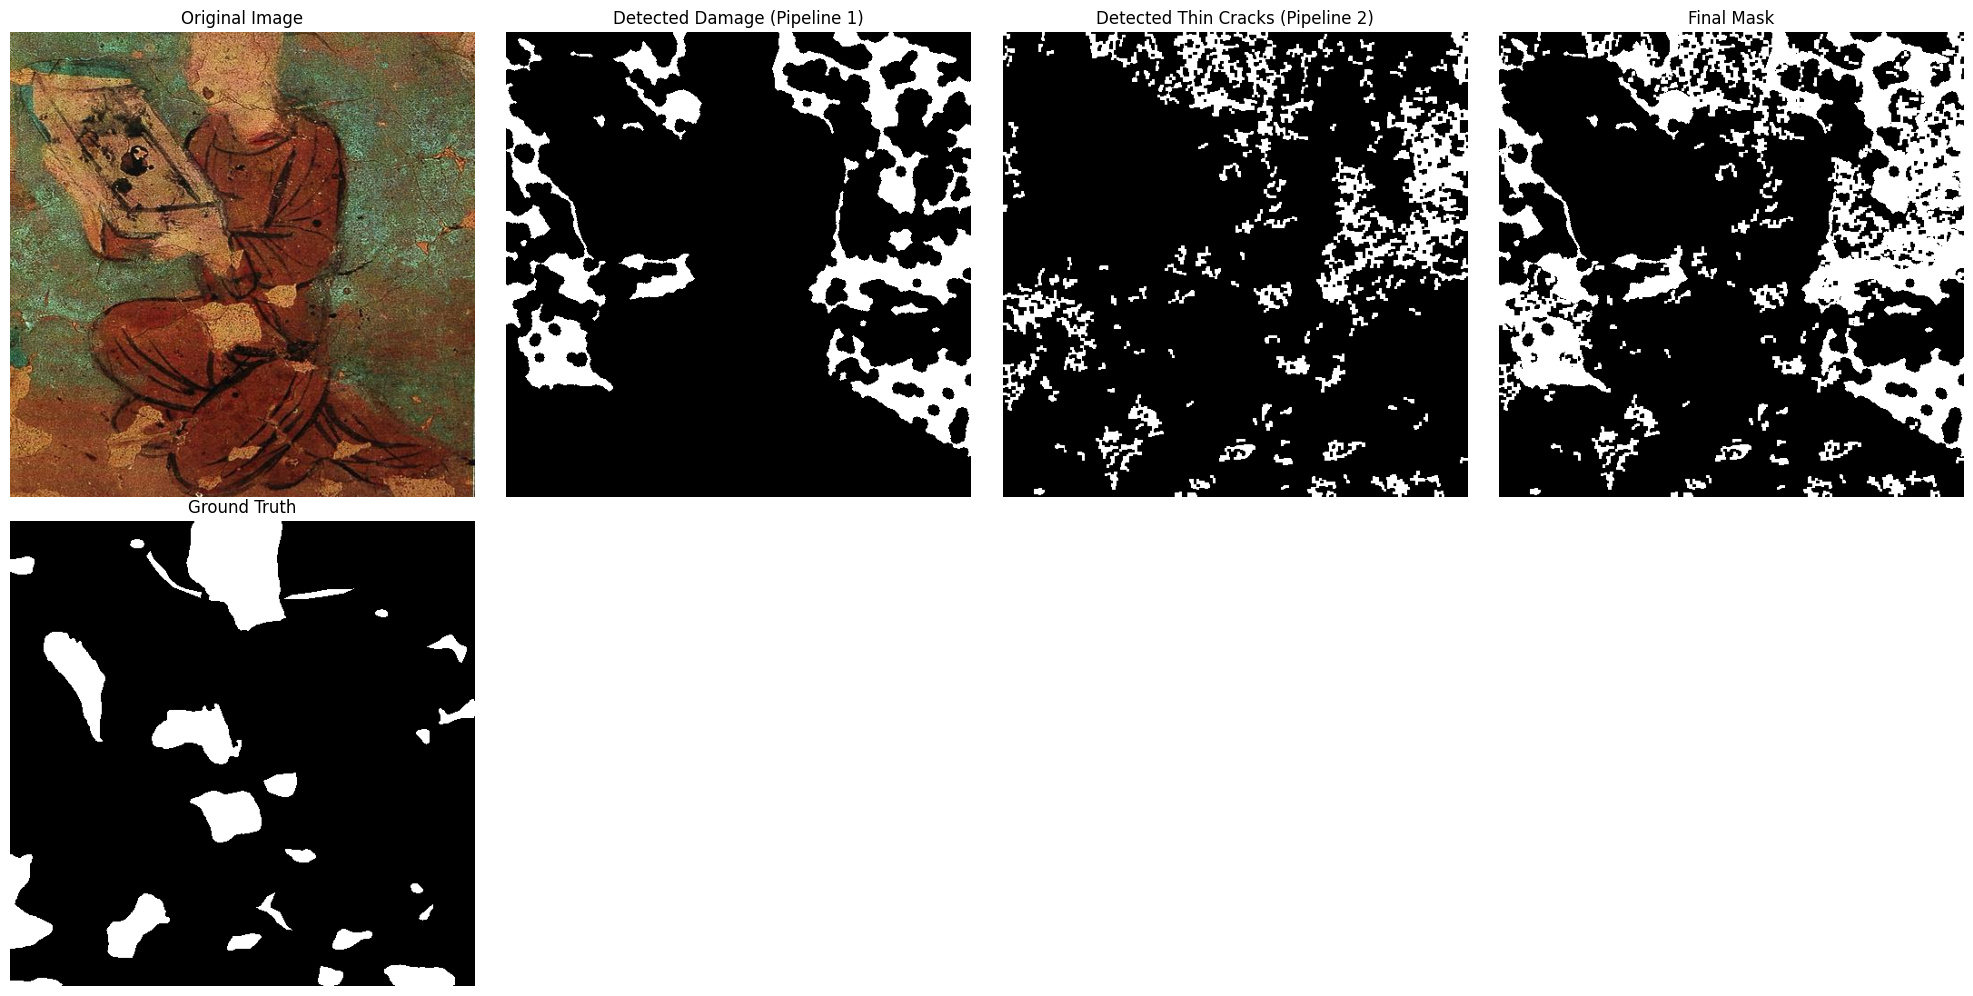

Metrics for 000795.png: Damage - {'iou': np.float64(0.01285849107360066), 'dice': np.float64(0.025390498634382124), 'precision': np.float64(0.0220637848269969), 'recall': np.float64(0.0298985096757216), 'accuracy': np.float64(0.7127113342296115), 'tp': np.int64(981), 'fp': np.int64(43481), 'fn': np.int64(31830), 'tn': np.int64(185852)}, Thin Cracks - {'iou': np.float64(0.18315686991805913), 'dice': np.float64(0.30960707674332727), 'precision': np.float64(0.29892460916213365), 'recall': np.float64(0.3210813446916863), 'accuracy': np.float64(0.8207702636725587), 'tp': np.int64(10535), 'fp': np.int64(24708), 'fn': np.int64(22276), 'tn': np.int64(204625)}, Final - {'iou': np.float64(0.35544435928274143), 'dice': np.float64(0.656587052665464), 'precision': np.float64(0.41461459920964505), 'recall': np.float64(2.19840221561029), 'accuracy': np.float64(4.401935577398675)}


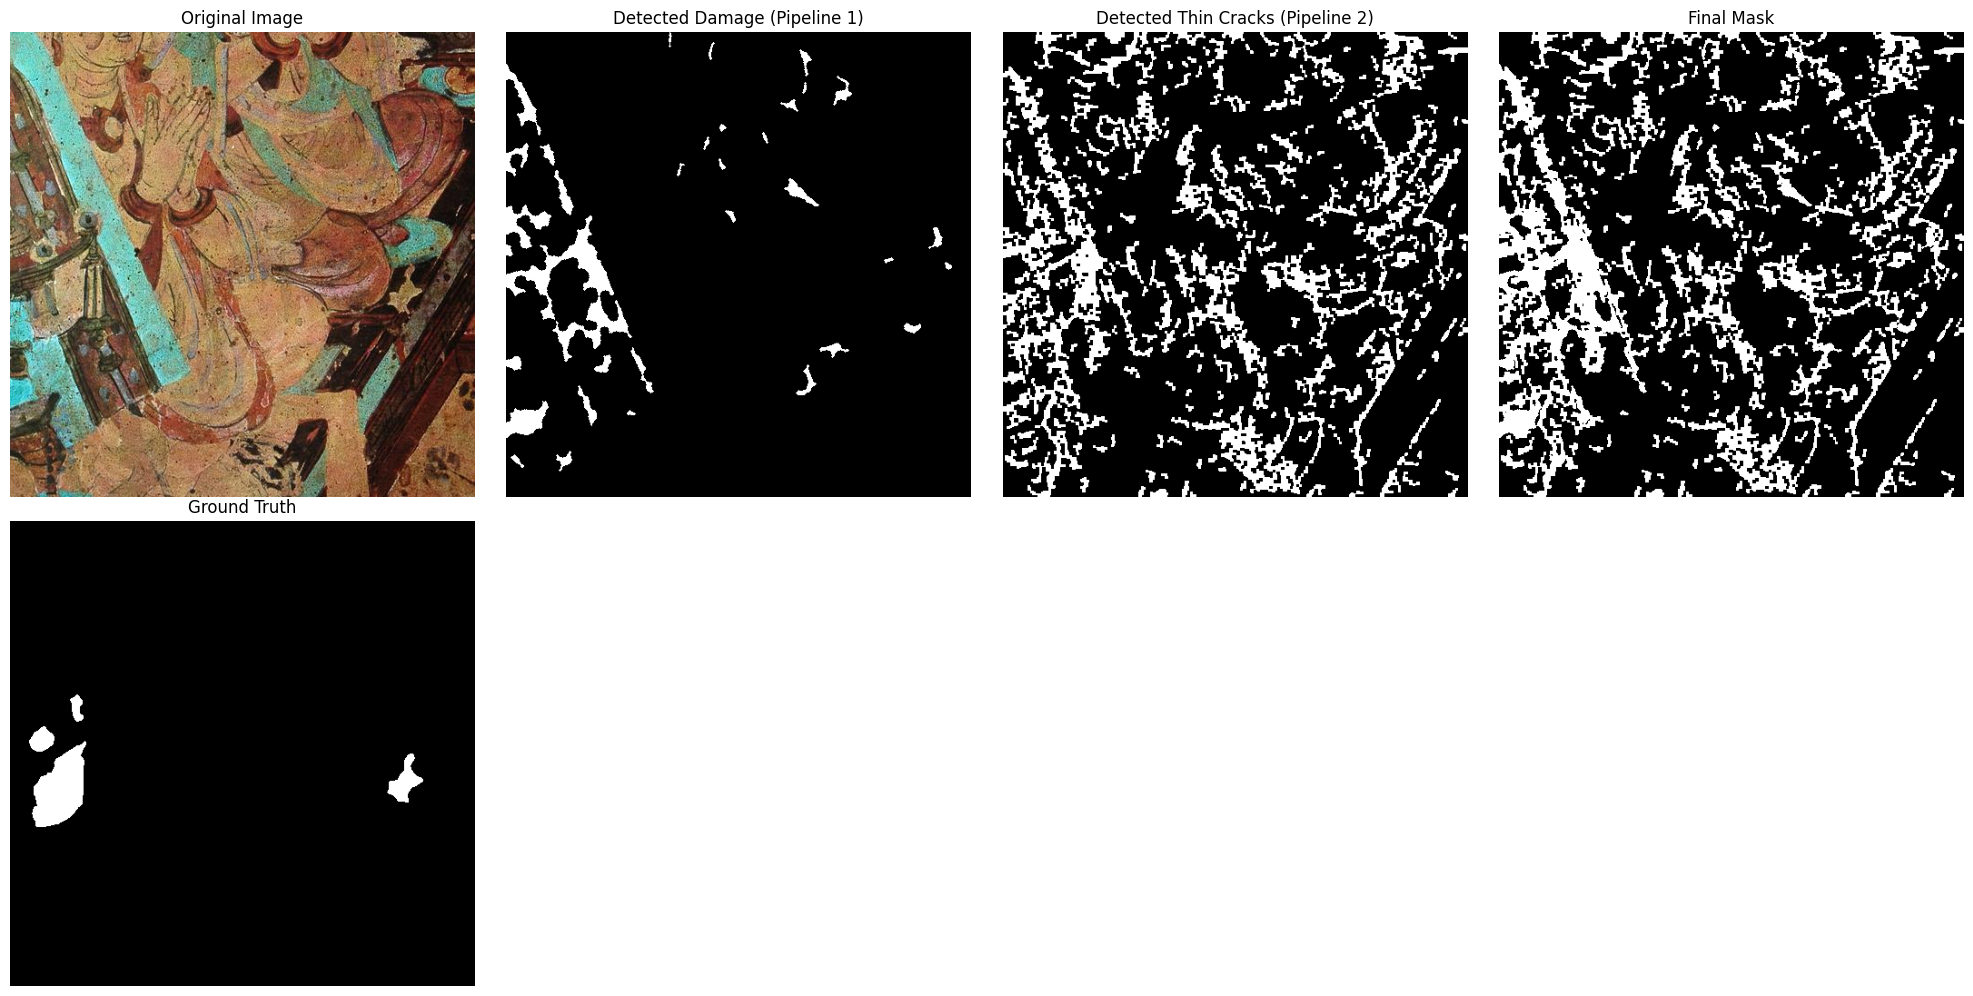

Metrics for 001139.png: Damage - {'iou': np.float64(0.03167393045045277), 'dice': np.float64(0.06140298690656257), 'precision': np.float64(0.04477223435620197), 'recall': np.float64(0.09769026900838881), 'accuracy': np.float64(0.9398231506349952), 'tp': np.int64(516), 'fp': np.int64(11009), 'fn': np.int64(4766), 'tn': np.int64(245853)}, Thin Cracks - {'iou': np.float64(0.03621110584725449), 'dice': np.float64(0.06989136795639077), 'precision': np.float64(0.03813040254251918), 'recall': np.float64(0.41840212051904535), 'accuracy': np.float64(0.7756156921395279), 'tp': np.int64(2210), 'fp': np.int64(55749), 'fn': np.int64(3072), 'tn': np.int64(201113)}, Final - {'iou': np.float64(0.39143415235565043), 'dice': np.float64(0.7260661021825351), 'precision': np.float64(0.4521790669328755), 'recall': np.float64(2.660348448199849), 'accuracy': np.float64(5.152618408210173)}


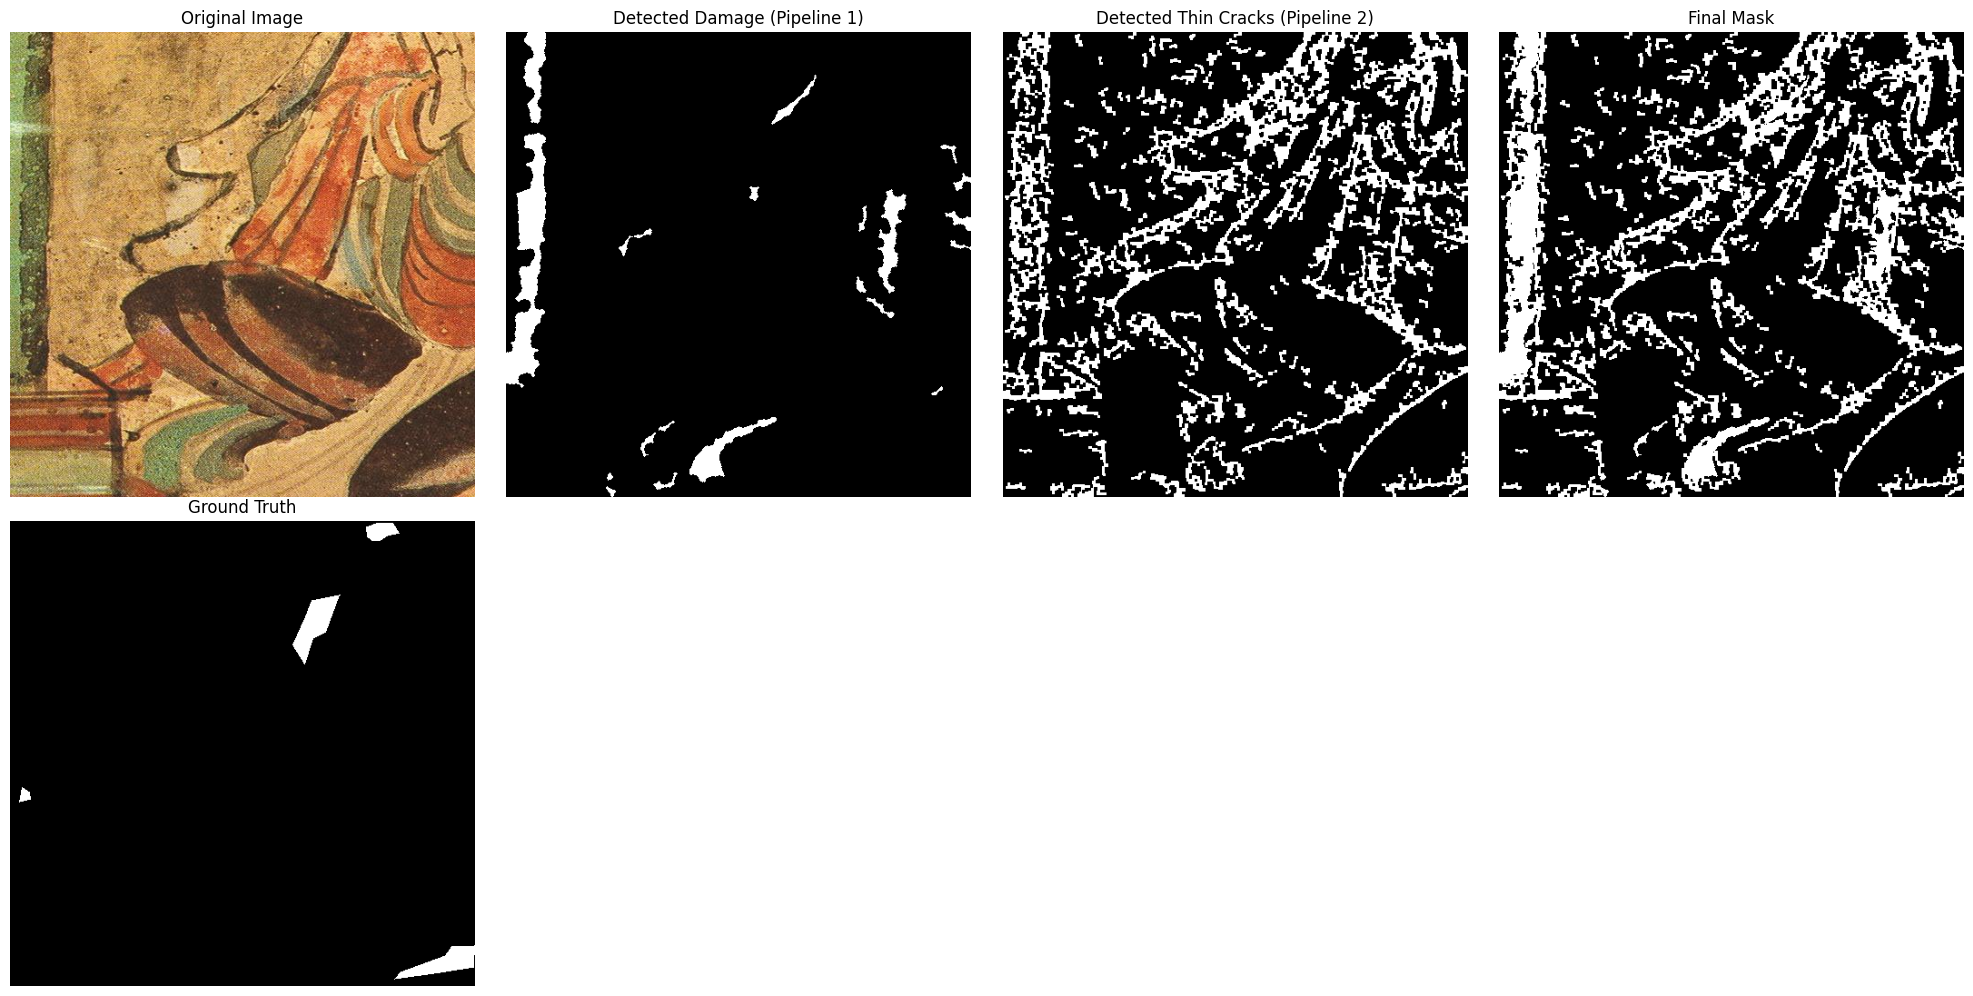

Metrics for 000970.png: Damage - {'iou': np.float64(0.0005523845209260182), 'dice': np.float64(0.001104159060170276), 'precision': np.float64(0.0007195395746146834), 'recall': np.float64(0.0023721668417574678), 'accuracy': np.float64(0.9378814697267994), 'tp': np.int64(9), 'fp': np.int64(12499), 'fn': np.int64(3785), 'tn': np.int64(245851)}, Thin Cracks - {'iou': np.float64(0.01482545066230451), 'dice': np.float64(0.029217735215907512), 'precision': np.float64(0.015619019865213161), 'recall': np.float64(0.22588297331948262), 'accuracy': np.float64(0.7827568054207505), 'tp': np.int64(857), 'fp': np.int64(54012), 'fn': np.int64(2937), 'tn': np.int64(204338)}, Final - {'iou': np.float64(0.4043975915392266), 'dice': np.float64(0.7516611802964198), 'precision': np.float64(0.4657452038445838), 'recall': np.float64(2.886231421519332), 'accuracy': np.float64(5.90370178223456)}


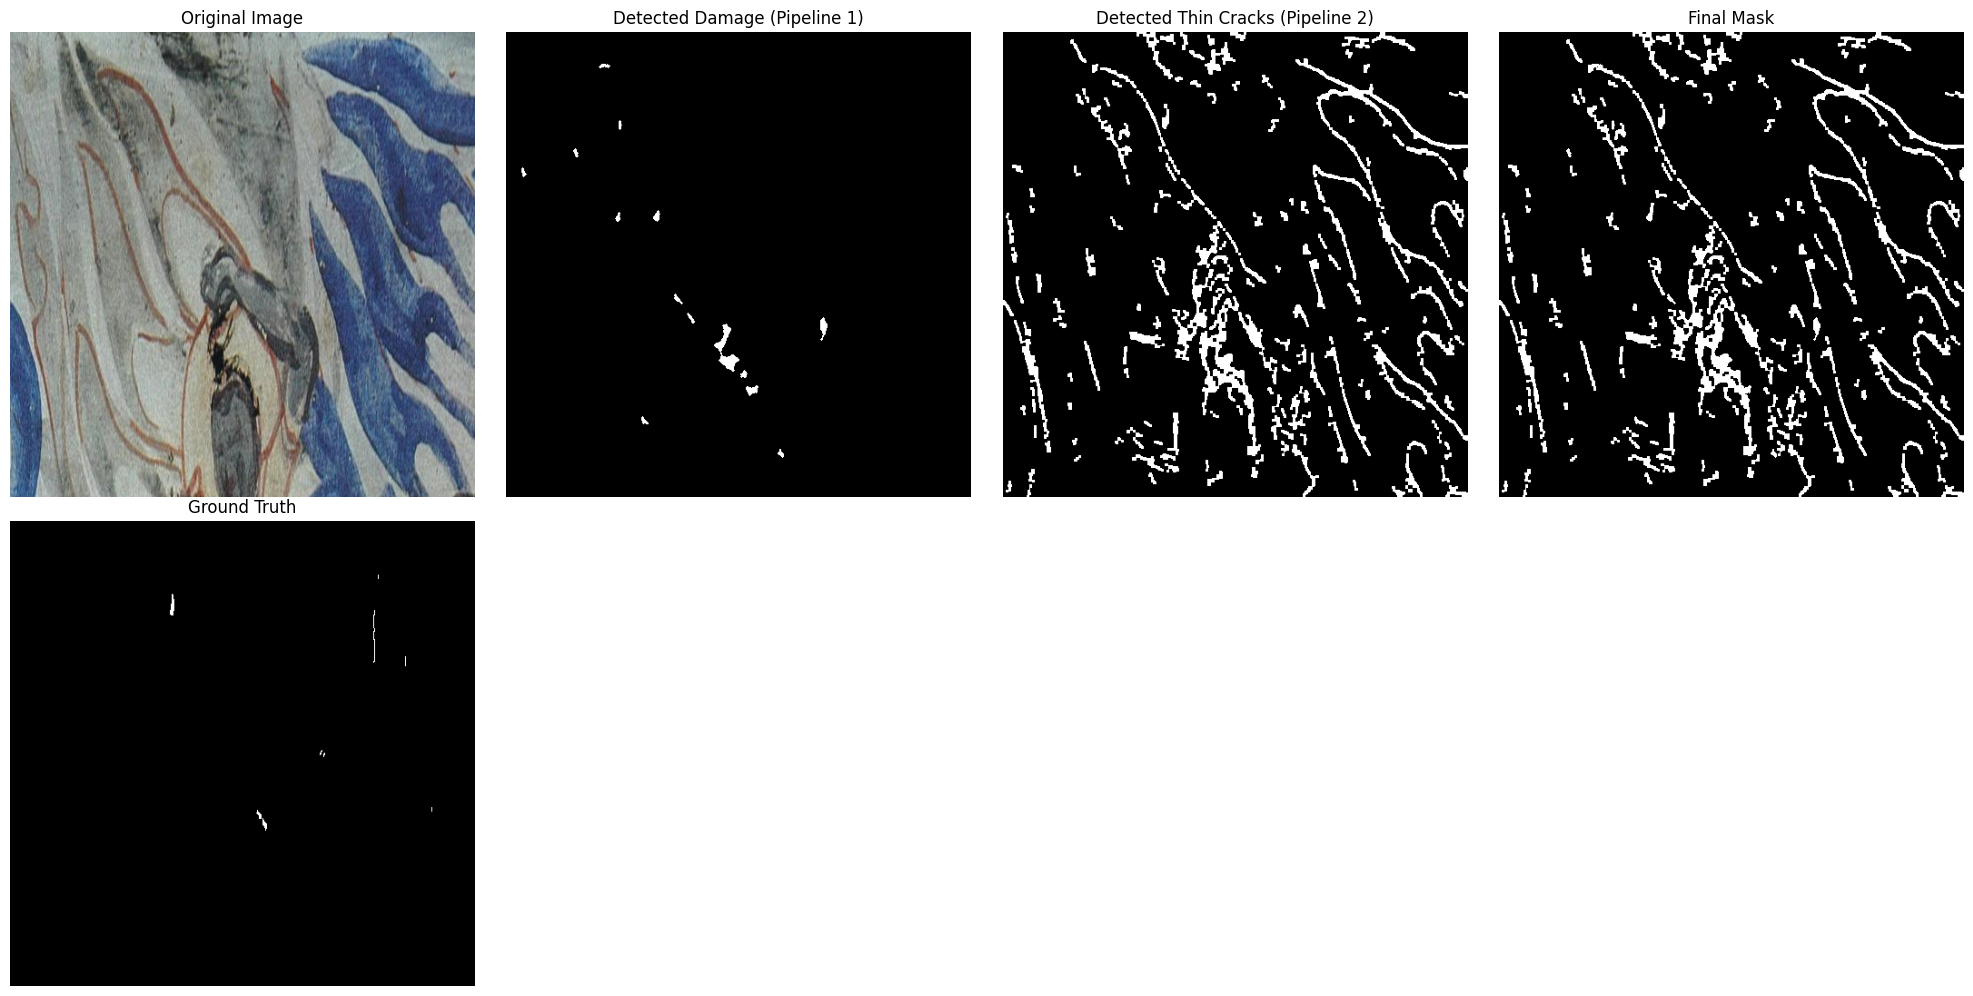

Metrics for img_728crop_0_1.png: Damage - {'iou': np.float64(7.358351723798122e-10), 'dice': np.float64(7.358351723798122e-10), 'precision': np.float64(8.952551469156175e-10), 'recall': np.float64(4.132231387883341e-09), 'accuracy': np.float64(0.9948158264160354), 'tp': np.int64(0), 'fp': np.int64(1117), 'fn': np.int64(242), 'tn': np.int64(260785)}, Thin Cracks - {'iou': np.float64(0.006274869949254864), 'dice': np.float64(0.012471482927282453), 'precision': np.float64(0.006293652659210467), 'recall': np.float64(0.6776859517450994), 'accuracy': np.float64(0.9009246826175654), 'tp': np.int64(164), 'fp': np.int64(25894), 'fn': np.int64(78), 'tn': np.int64(236008)}, Final - {'iou': np.float64(0.41053439744380166), 'dice': np.float64(0.7638599307050705), 'precision': np.float64(0.4718999738285906), 'recall': np.float64(3.5639173732644314), 'accuracy': np.float64(6.802383422859946)}


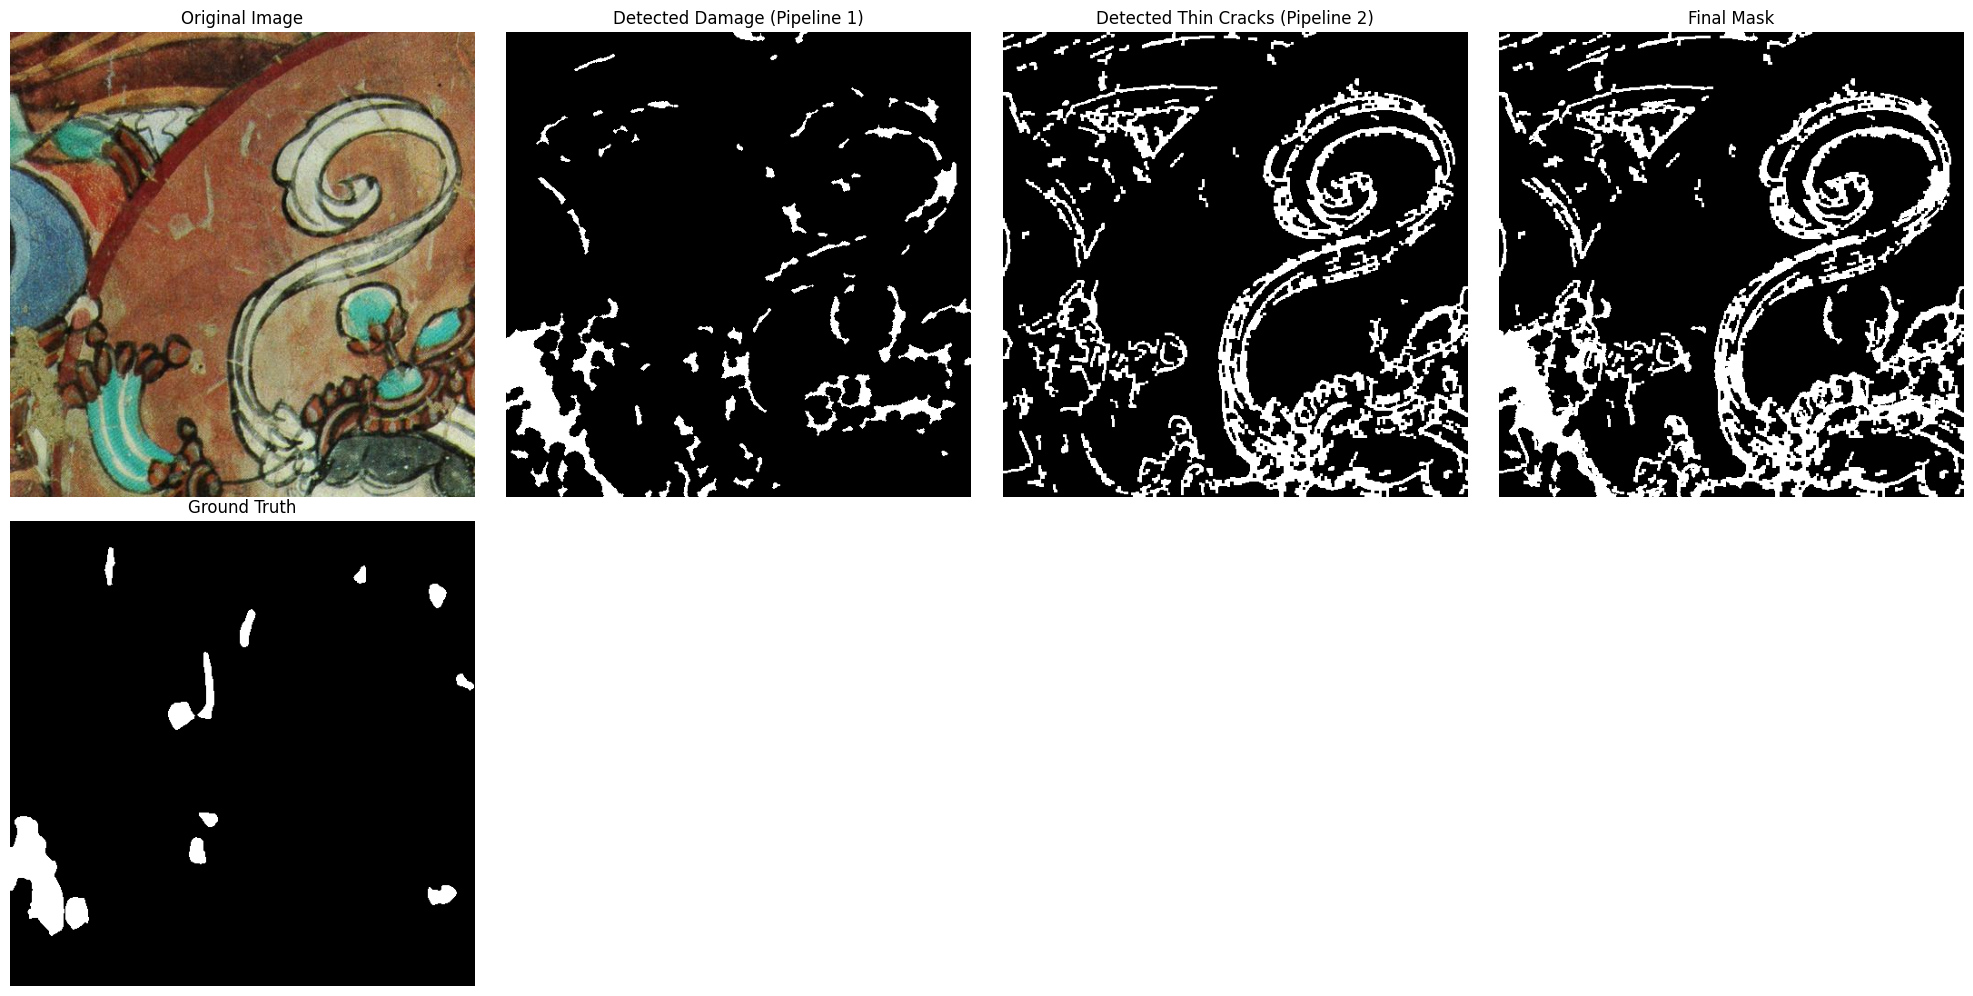

Metrics for 000248.png: Damage - {'iou': np.float64(0.21948428755590355), 'dice': np.float64(0.35996246902486556), 'precision': np.float64(0.25849456159117845), 'recall': np.float64(0.5925639894536007), 'accuracy': np.float64(0.9271392822268404), 'tp': np.int64(5371), 'fp': np.int64(15407), 'fn': np.int64(3693), 'tn': np.int64(237673)}, Thin Cracks - {'iou': np.float64(0.022931992211699972), 'dice': np.float64(0.04483580996065243), 'precision': np.float64(0.026889055163779235), 'recall': np.float64(0.13481906452616738), 'accuracy': np.float64(0.8013839721687264), 'tp': np.int64(1222), 'fp': np.int64(44224), 'fn': np.int64(7842), 'tn': np.int64(208856)}, Final - {'iou': np.float64(0.5083544722917304), 'dice': np.float64(0.9420677756559737), 'precision': np.float64(0.5748288154879321), 'recall': np.float64(4.22731101849133), 'accuracy': np.float64(7.590831756600988)}


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile



Average Metrics for Damage Detection:
iou: 0.0690
dice: 0.1136
precision: 0.0997
recall: 0.2735
accuracy: 0.8508

Average Metrics for Thin Cracks Detection:
iou: 0.0435
dice: 0.0806
precision: 0.0729
recall: 0.2583
accuracy: 0.8444

Average Metrics for Final Detection (Union of Damage and Thin Cracks):
iou: 0.0711
dice: 0.1221
precision: 0.0869
recall: 0.4663
accuracy: 0.7627


In [36]:
# Ejecutar los detectores en todas las imágenes y mostrar el promedio de métricas, además mostrar las 10 primeras imágenes con las máscaras calculadas.

images_folder = 'dataset-&-labels/images'
labels_folder = 'dataset-&-labels/labels'

metrics_avg_damage = {
    "iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0,
}
metrics_avg_thin_cracks = {
    "iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0,
}

metrics_avg_final = {
    "iou": 0.0, "dice": 0.0, "precision": 0.0, "recall": 0.0, "accuracy": 0.0,
}

i= 0

for img in os.listdir(images_folder):
    img_path = os.path.join(images_folder, img)
    label_path = os.path.join(labels_folder, img.replace('.jpg', '.png').replace('.png', '.png'))

    img_bgr = cv2.imread(img_path)
    label_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

    if img_bgr is None or label_mask is None:
        print(f"Error loading image or label for {img}. Skipping.")
        continue

    # Detect damage
    damage_mask = detect_damage_02(
        img_bgr.copy(), **damage_params)

    # Detect thin cracks
    thin_crack_mask, grayscale, edge_response, edge_mask = detect_thin_cracks(
        img_bgr.copy(), **param_sets_cracks)
    
    # Union mask
    thin_crack_mask = thin_crack_mask.astype(np.uint8) * 255  # Asegurar que sea binaria
    damage_mask = damage_mask.astype(np.uint8) * 255  # Asegurar que sea binaria
    final_mask = cv2.bitwise_or(damage_mask, thin_crack_mask)


    # Calculate metrics for damage detection
    metrics_damage = calculate_metrics(damage_mask, label_mask)
    
    # Calculate metrics for thin cracks detection
    metrics_thin_cracks = calculate_metrics(thin_crack_mask, label_mask)

    # Calculate metrics for final detection (union of damage and thin cracks)
    metrics_final = calculate_metrics(final_mask, label_mask)

    # Accumulate metrics
    for key in metrics_avg_damage.keys():
        metrics_avg_damage[key] += metrics_damage[key]
    
    for key in metrics_avg_thin_cracks.keys():
        metrics_avg_thin_cracks[key] += metrics_thin_cracks[key]

    # Accumulate final metrics
    for key in metrics_avg_final.keys():
        metrics_avg_final[key] += metrics_final[key]
    
    # Show results for the first 10 images
    if i < 10:
        show_images([img_bgr, damage_mask, thin_crack_mask, final_mask, label_mask],
                    titles=["Original Image", "Detected Damage (Pipeline 1)", "Detected Thin Cracks (Pipeline 2)", "Final Mask", "Ground Truth"],
                    cmap_list=['bgr', 'gray', 'gray', 'gray', 'gray'])
        print(f"Metrics for {img}: Damage - {metrics_damage}, Thin Cracks - {metrics_thin_cracks}, Final - {metrics_avg_final}")

    i += 1

# Average metrics
num_images = i
for key in metrics_avg_damage.keys():
    metrics_avg_damage[key] /= num_images
    metrics_avg_thin_cracks[key] /= num_images
    metrics_avg_final[key] /= num_images

print("\nAverage Metrics for Damage Detection:")
for key, value in metrics_avg_damage.items():
    print(f"{key}: {value:.4f}")

print("\nAverage Metrics for Thin Cracks Detection:")
for key, value in metrics_avg_thin_cracks.items():
    print(f"{key}: {value:.4f}")

print("\nAverage Metrics for Final Detection (Union of Damage and Thin Cracks):")
for key, value in metrics_avg_final.items():
    print(f"{key}: {value:.4f}")
